Question 1

In [1]:
import sys
print(sys.executable)

c:\Users\PRANAV SINGH RAWAT\OneDrive\Desktop\PRANAV\DRDO internship\CS6910 Assignment 1\dl_env\Scripts\python.exe


In [2]:
!pip install wandb

In [3]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import wandb
from keras.datasets import fashion_mnist

In [5]:
wandb.init(project="cs6910_assignment1")
config = wandb.config

In [6]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [7]:
class_names = [
"T-shirt/top",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"
]

In [8]:
sample_images = []
sample_labels = []

for i in range(10):
    idx = np.where(y_train == i)[0][0]
    sample_images.append(x_train[idx])
    sample_labels.append(class_names[i])

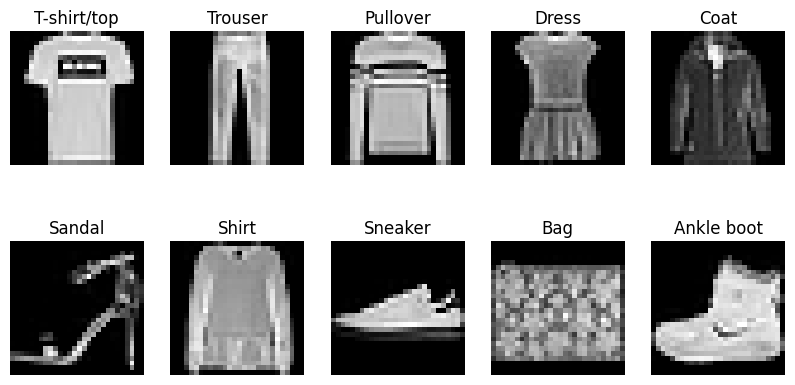

In [9]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.title(sample_labels[i])
    plt.axis("off")

plt.show()

In [10]:
images = []

for i in range(10):
    images.append(wandb.Image(sample_images[i], caption=sample_labels[i]))

wandb.log({"Fashion-MNIST Samples": images})

Question 2

In [11]:
#initializing parameters(weights and biases)
def initialize_parameters(input_size, hidden_size, output_size, num_layers, init_type="random"):

    parameters = {}
    layer_sizes = [input_size] + [hidden_size]*num_layers + [output_size]

    for l in range(1, len(layer_sizes)):

        if init_type == "random":
            parameters["W"+str(l)] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * 0.01

        elif init_type == "Xavier":
            parameters["W"+str(l)] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * np.sqrt(1/layer_sizes[l-1])

        parameters["b"+str(l)] = np.zeros((layer_sizes[l],1))

    return parameters

params = initialize_parameters(784,128,10,2,"Xavier")

for key in params:
    print(key, params[key].shape)

W1 (128, 784)
b1 (128, 1)
W2 (128, 128)
b2 (128, 1)
W3 (10, 128)
b3 (10, 1)


In [12]:
#activation functions
def activation(Z, activation_type):

    if activation_type == "identity":
        return Z

    elif activation_type == "sigmoid":
        return 1/(1+np.exp(-Z))

    elif activation_type == "tanh":
        return np.tanh(Z)

    elif activation_type == "ReLU":
        return np.maximum(0,Z)

In [13]:
#adding softmax 
def softmax(Z):

    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [14]:
#derivative of activation functions
def activation_derivative(Z, activation_type):

    if activation_type == "identity":
        return np.ones_like(Z)

    elif activation_type == "sigmoid":
        s = 1/(1+np.exp(-Z))
        return s*(1-s)

    elif activation_type == "tanh":
        return 1 - np.tanh(Z)**2

    elif activation_type == "ReLU":
        return (Z > 0).astype(float)

In [15]:
#testing activation functions
Z = np.array([-2,-1,0,1,2])

print("Sigmoid:", activation(Z,"sigmoid"))
print("Tanh:", activation(Z,"tanh"))
print("ReLU:", activation(Z,"ReLU"))

Sigmoid: [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
Tanh: [-0.96402758 -0.76159416  0.          0.76159416  0.96402758]
ReLU: [0 0 0 1 2]


In [16]:
#forward propogation
def forward_propagation(X, parameters, activation_type):

    caches = {}
    A = X
    L = len(parameters)//2

    for l in range(1, L):

        W = parameters["W"+str(l)]
        b = parameters["b"+str(l)]

        Z = np.dot(W,A) + b
        A = activation(Z, activation_type)

        caches["Z"+str(l)] = Z
        caches["A"+str(l)] = A

    # Output layer
    W = parameters["W"+str(L)]
    b = parameters["b"+str(L)]

    Z = np.dot(W,A) + b
    A = softmax(Z)

    caches["Z"+str(L)] = Z
    caches["A"+str(L)] = A

    return A, caches

#test
X_sample = np.random.randn(784,1)

params = initialize_parameters(784,128,10,2,"Xavier")

output, cache = forward_propagation(X_sample, params, "ReLU")

print(output.shape)
print(np.sum(output))

(10, 1)
1.0000000000000002


In [17]:
#cross entorpy loss
def compute_loss(Y_hat, Y):

    m = Y.shape[1]

    loss = -np.sum(Y * np.log(Y_hat + 1e-9)) / m

    return loss
#testing loss function
Y_hat = np.array([[0.1],[0.7],[0.2]])
Y = np.array([[0],[1],[0]])

print(compute_loss(Y_hat,Y))

0.3566749425101611


In [18]:
#backpropogation
def backpropagation(X, Y, parameters, caches, activation_type):

    grads = {}
    m = X.shape[1]
    L = len(parameters)//2

    A_final = caches["A"+str(L)]

    # Output layer gradient
    dZ = A_final - Y

    for l in reversed(range(1, L+1)):

        if l == 1:
            A_prev = X
        else:
            A_prev = caches["A"+str(l-1)]

        W = parameters["W"+str(l)]

        grads["dW"+str(l)] = (1/m) * np.dot(dZ, A_prev.T)
        grads["db"+str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:

            Z_prev = caches["Z"+str(l-1)]
            dA_prev = np.dot(W.T, dZ)

            dZ = dA_prev * activation_derivative(Z_prev, activation_type)

    return grads
#testing backpropagation
X_sample = np.random.randn(784,5)

params = initialize_parameters(784,128,10,2,"Xavier")

Y_sample = np.zeros((10,5))
Y_sample[3] = 1

output, cache = forward_propagation(X_sample, params, "ReLU")

grads = backpropagation(X_sample, Y_sample, params, cache, "ReLU")

for g in grads:
    print(g, grads[g].shape)

dW3 (10, 128)
db3 (10, 1)
dW2 (128, 128)
db2 (128, 1)
dW1 (128, 784)
db1 (128, 1)


In [19]:
#one hot encoding
def one_hot(Y, num_classes=10):

    one_hot_Y = np.zeros((num_classes, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1

    return one_hot_Y
#testing one hot encoding
print(one_hot(np.array([3,1,2])))

[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [20]:
#flattening images
X_train_flat = x_train.reshape(x_train.shape[0], -1).T / 255
X_test_flat = x_test.reshape(x_test.shape[0], -1).T / 255

Y_train_oh = one_hot(y_train)
Y_test_oh = one_hot(y_test)

print(X_train_flat.shape)
print(Y_train_oh.shape)

(784, 60000)
(10, 60000)


In [21]:
#mini batch creation
def create_mini_batches(X, Y, batch_size):

    m = X.shape[1]
    permutation = np.random.permutation(m)

    X_shuffled = X[:, permutation]
    Y_shuffled = Y[:, permutation]

    mini_batches = []

    for i in range(0, m, batch_size):

        X_batch = X_shuffled[:, i:i+batch_size]
        Y_batch = Y_shuffled[:, i:i+batch_size]

        mini_batches.append((X_batch, Y_batch))

    return mini_batches

In [22]:
#accuracy function
def compute_accuracy(Y_hat, Y):

    predictions = np.argmax(Y_hat, axis=0)
    labels = np.argmax(Y, axis=0)

    return np.mean(predictions == labels)

In [23]:
#stochastic gradient descent
def update_parameters_sgd(parameters, grads, learning_rate):

    L = len(parameters)//2

    for l in range(1, L+1):

        parameters["W"+str(l)] -= learning_rate * grads["dW"+str(l)]
        parameters["b"+str(l)] -= learning_rate * grads["db"+str(l)]

    return parameters
#testing sgd
params = initialize_parameters(784,128,10,2,"Xavier")

X_sample = np.random.randn(784,5)

Y_sample = np.zeros((10,5))
Y_sample[3] = 1

output, cache = forward_propagation(X_sample, params, "ReLU")

grads = backpropagation(X_sample, Y_sample, params, cache, "ReLU")

params = update_parameters_sgd(params, grads, 0.01)

print("Update completed")

Update completed


In [24]:
#training loop
def train_network(X, Y, parameters, epochs, batch_size, learning_rate,
                  activation_type, optimizer="sgd"):

    L = len(parameters)//2

    v, s = None, None
    t = 1

    if optimizer in ["momentum","nag"]:
        v = initialize_velocity(parameters)

    if optimizer in ["rmsprop"]:
        s = initialize_rmsprop(parameters)

    if optimizer in ["adam","nadam"]:
        v, s = initialize_adam(parameters)

    for epoch in range(epochs):

        mini_batches = create_mini_batches(X,Y,batch_size)

        epoch_loss = 0

        for X_batch, Y_batch in mini_batches:

            Y_hat, caches = forward_propagation(X_batch, parameters, activation_type)

            loss = compute_loss(Y_hat, Y_batch)

            grads = backpropagation(X_batch, Y_batch, parameters, caches, activation_type)

            if optimizer == "sgd":

                parameters = update_parameters_sgd(parameters, grads, learning_rate)

            elif optimizer == "momentum":

                parameters, v = update_parameters_momentum(parameters, grads, v, learning_rate)

            elif optimizer == "nag":

                parameters, v = update_parameters_nag(parameters, grads, v, learning_rate)

            elif optimizer == "rmsprop":

                parameters, s = update_parameters_rmsprop(parameters, grads, s, learning_rate)

            elif optimizer == "adam":

                parameters, v, s = update_parameters_adam(parameters, grads, v, s, t, learning_rate)

            elif optimizer == "nadam":

                parameters, v, s = update_parameters_nadam(parameters, grads, v, s, t, learning_rate)

            epoch_loss += loss
            t += 1

        epoch_loss /= len(mini_batches)

        Y_hat_full, _ = forward_propagation(X, parameters, activation_type)
        acc = compute_accuracy(Y_hat_full, Y)


        val_acc = evaluate_model(X_val, Y_val, parameters, activation_type)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {acc:.4f}")
        print(f"Epoch {epoch+1}, Loss:{epoch_loss:.4f}, Train Acc:{acc:.4f}, Val Acc:{val_acc:.4f}")
        wandb.log({
            "epoch": epoch,
            "loss": epoch_loss,
            "train_accuracy": acc,
            "val_accuracy": val_acc
        })


    return parameters

In [25]:
#momnetum based gradient descent
def initialize_velocity(parameters):

    v = {}
    L = len(parameters)//2

    for l in range(1, L+1):

        v["dW"+str(l)] = np.zeros_like(parameters["W"+str(l)])
        v["db"+str(l)] = np.zeros_like(parameters["b"+str(l)])

    return v

def update_parameters_momentum(parameters, grads, v, learning_rate, beta=0.9):

    L = len(parameters)//2

    for l in range(1, L+1):

        v["dW"+str(l)] = beta*v["dW"+str(l)] + (1-beta)*grads["dW"+str(l)]
        v["db"+str(l)] = beta*v["db"+str(l)] + (1-beta)*grads["db"+str(l)]

        parameters["W"+str(l)] -= learning_rate * v["dW"+str(l)]
        parameters["b"+str(l)] -= learning_rate * v["db"+str(l)]

    return parameters, v
#testing 
params = initialize_parameters(784,128,10,2,"Xavier")

v = initialize_velocity(params)

X_sample = np.random.randn(784,5)

Y_sample = np.zeros((10,5))
Y_sample[3] = 1

output, cache = forward_propagation(X_sample, params, "ReLU")

grads = backpropagation(X_sample, Y_sample, params, cache, "ReLU")

params, v = update_parameters_momentum(params, grads, v, 0.01)

print("Momentum update working")


Momentum update working


In [26]:
#initialization of RMSprop
def initialize_rmsprop(parameters):

    s = {}
    L = len(parameters)//2

    for l in range(1, L+1):

        s["dW"+str(l)] = np.zeros_like(parameters["W"+str(l)])
        s["db"+str(l)] = np.zeros_like(parameters["b"+str(l)])

    return s
#rmsprop update
def update_parameters_rmsprop(parameters, grads, s, learning_rate, beta=0.9, epsilon=1e-8):

    L = len(parameters)//2

    for l in range(1, L+1):

        s["dW"+str(l)] = beta*s["dW"+str(l)] + (1-beta)*(grads["dW"+str(l)]**2)
        s["db"+str(l)] = beta*s["db"+str(l)] + (1-beta)*(grads["db"+str(l)]**2)

        parameters["W"+str(l)] -= learning_rate * grads["dW"+str(l)] / (np.sqrt(s["dW"+str(l)]) + epsilon)
        parameters["b"+str(l)] -= learning_rate * grads["db"+str(l)] / (np.sqrt(s["db"+str(l)]) + epsilon)

    return parameters, s

In [27]:
#adam variables initialization
def initialize_adam(parameters):

    v = {}
    s = {}

    L = len(parameters)//2

    for l in range(1, L+1):

        v["dW"+str(l)] = np.zeros_like(parameters["W"+str(l)])
        v["db"+str(l)] = np.zeros_like(parameters["b"+str(l)])

        s["dW"+str(l)] = np.zeros_like(parameters["W"+str(l)])
        s["db"+str(l)] = np.zeros_like(parameters["b"+str(l)])

    return v, s
#adam update
def update_parameters_adam(parameters, grads, v, s, t, learning_rate,
                           beta1=0.9, beta2=0.999, epsilon=1e-8):

    L = len(parameters)//2

    for l in range(1, L+1):

        v["dW"+str(l)] = beta1*v["dW"+str(l)] + (1-beta1)*grads["dW"+str(l)]
        v["db"+str(l)] = beta1*v["db"+str(l)] + (1-beta1)*grads["db"+str(l)]

        s["dW"+str(l)] = beta2*s["dW"+str(l)] + (1-beta2)*(grads["dW"+str(l)]**2)
        s["db"+str(l)] = beta2*s["db"+str(l)] + (1-beta2)*(grads["db"+str(l)]**2)

        v_corrected_dW = v["dW"+str(l)] / (1-beta1**t)
        v_corrected_db = v["db"+str(l)] / (1-beta1**t)

        s_corrected_dW = s["dW"+str(l)] / (1-beta2**t)
        s_corrected_db = s["db"+str(l)] / (1-beta2**t)

        parameters["W"+str(l)] -= learning_rate * v_corrected_dW / (np.sqrt(s_corrected_dW)+epsilon)
        parameters["b"+str(l)] -= learning_rate * v_corrected_db / (np.sqrt(s_corrected_db)+epsilon)

    return parameters, v, s
#test adam
params = initialize_parameters(784,128,10,2,"Xavier")

v, s = initialize_adam(params)

X_sample = np.random.randn(784,5)

Y_sample = np.zeros((10,5))
Y_sample[3] = 1

output, cache = forward_propagation(X_sample, params, "ReLU")

grads = backpropagation(X_sample, Y_sample, params, cache, "ReLU")

params, v, s = update_parameters_adam(params, grads, v, s, t=1, learning_rate=0.001)

print("Adam working")

Adam working


In [28]:
#implement NAG
def update_parameters_nag(parameters, grads, v, learning_rate, beta=0.9):

    L = len(parameters)//2

    for l in range(1, L+1):

        v_prev_dW = v["dW"+str(l)]
        v_prev_db = v["db"+str(l)]

        v["dW"+str(l)] = beta*v["dW"+str(l)] + (1-beta)*grads["dW"+str(l)]
        v["db"+str(l)] = beta*v["db"+str(l)] + (1-beta)*grads["db"+str(l)]

        parameters["W"+str(l)] -= learning_rate*(beta*v["dW"+str(l)] + (1-beta)*grads["dW"+str(l)])
        parameters["b"+str(l)] -= learning_rate*(beta*v["db"+str(l)] + (1-beta)*grads["db"+str(l)])

    return parameters, v
#nadam update
def update_parameters_nadam(parameters, grads, v, s, t, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):

    L = len(parameters)//2

    for l in range(1, L+1):

        v["dW"+str(l)] = beta1*v["dW"+str(l)] + (1-beta1)*grads["dW"+str(l)]
        v["db"+str(l)] = beta1*v["db"+str(l)] + (1-beta1)*grads["db"+str(l)]

        s["dW"+str(l)] = beta2*s["dW"+str(l)] + (1-beta2)*(grads["dW"+str(l)]**2)
        s["db"+str(l)] = beta2*s["db"+str(l)] + (1-beta2)*(grads["db"+str(l)]**2)

        v_corrected_dW = v["dW"+str(l)] / (1-beta1**t)
        v_corrected_db = v["db"+str(l)] / (1-beta1**t)

        s_corrected_dW = s["dW"+str(l)] / (1-beta2**t)
        s_corrected_db = s["db"+str(l)] / (1-beta2**t)

        nadam_dW = beta1*v_corrected_dW + (1-beta1)*grads["dW"+str(l)]/(1-beta1**t)
        nadam_db = beta1*v_corrected_db + (1-beta1)*grads["db"+str(l)]/(1-beta1**t)

        parameters["W"+str(l)] -= learning_rate * nadam_dW/(np.sqrt(s_corrected_dW)+epsilon)
        parameters["b"+str(l)] -= learning_rate * nadam_db/(np.sqrt(s_corrected_db)+epsilon)

    return parameters, v, s

In [29]:
#validation split
split = 54000

X_val = X_train_flat[:, split:]
Y_val = Y_train_oh[:, split:]

X_train_new = X_train_flat[:, :split]
Y_train_new = Y_train_oh[:, :split]

print(X_train_new.shape)
print(X_val.shape)
#validation accuracy function
def evaluate_model(X, Y, parameters, activation):

    Y_hat, _ = forward_propagation(X, parameters, activation)

    acc = compute_accuracy(Y_hat, Y)

    return acc

(784, 54000)
(784, 6000)


In [30]:
#W&B Config Cell
wandb.init(
    project="cs6910_assignment1",
    config={
        "epochs":5,
        "learning_rate":0.001,
        "batch_size":64,
        "hidden_size":128,
        "optimizer":"adam",
        "activation":"ReLU"
    }
)

config = wandb.config

In [31]:
#training the model
params = initialize_parameters(784, config.hidden_size, 10, 2, "Xavier")

trained_params = train_network(
    X_train_new,
    Y_train_new,
    params,
    epochs=config.epochs,
    batch_size=config.batch_size,
    learning_rate=config.learning_rate,
    activation_type=config.activation,
    optimizer=config.optimizer
)

Epoch 1, Loss: 0.5288, Accuracy: 0.8613
Epoch 1, Loss:0.5288, Train Acc:0.8613, Val Acc:0.8550
Epoch 2, Loss: 0.3811, Accuracy: 0.8729
Epoch 2, Loss:0.3811, Train Acc:0.8729, Val Acc:0.8657
Epoch 3, Loss: 0.3399, Accuracy: 0.8765
Epoch 3, Loss:0.3399, Train Acc:0.8765, Val Acc:0.8630
Epoch 4, Loss: 0.3130, Accuracy: 0.8827
Epoch 4, Loss:0.3130, Train Acc:0.8827, Val Acc:0.8705
Epoch 5, Loss: 0.2965, Accuracy: 0.8903
Epoch 5, Loss:0.2965, Train Acc:0.8903, Val Acc:0.8718


In [32]:
#training final model
params = initialize_parameters(784,128,10,2,"Xavier")

trained_params = train_network(
    X_train_new,
    Y_train_new,
    params,
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
    activation_type="ReLU",
    optimizer="adam"
)

Epoch 1, Loss: 0.5238, Accuracy: 0.8461
Epoch 1, Loss:0.5238, Train Acc:0.8461, Val Acc:0.8402
Epoch 2, Loss: 0.3747, Accuracy: 0.8561
Epoch 2, Loss:0.3747, Train Acc:0.8561, Val Acc:0.8453
Epoch 3, Loss: 0.3374, Accuracy: 0.8856
Epoch 3, Loss:0.3374, Train Acc:0.8856, Val Acc:0.8738
Epoch 4, Loss: 0.3145, Accuracy: 0.8921
Epoch 4, Loss:0.3145, Train Acc:0.8921, Val Acc:0.8753
Epoch 5, Loss: 0.2963, Accuracy: 0.8990
Epoch 5, Loss:0.2963, Train Acc:0.8990, Val Acc:0.8825
Epoch 6, Loss: 0.2813, Accuracy: 0.9033
Epoch 6, Loss:0.2813, Train Acc:0.9033, Val Acc:0.8783
Epoch 7, Loss: 0.2662, Accuracy: 0.9066
Epoch 7, Loss:0.2662, Train Acc:0.9066, Val Acc:0.8835
Epoch 8, Loss: 0.2560, Accuracy: 0.9076
Epoch 8, Loss:0.2560, Train Acc:0.9076, Val Acc:0.8820
Epoch 9, Loss: 0.2471, Accuracy: 0.9107
Epoch 9, Loss:0.2471, Train Acc:0.9107, Val Acc:0.8792
Epoch 10, Loss: 0.2378, Accuracy: 0.9160
Epoch 10, Loss:0.2378, Train Acc:0.9160, Val Acc:0.8885
Epoch 11, Loss: 0.2286, Accuracy: 0.9154
Epoch 1

In [33]:
#test accuracy
test_acc = evaluate_model(
    X_test_flat,
    Y_test_oh,
    trained_params,
    "ReLU"
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.8877


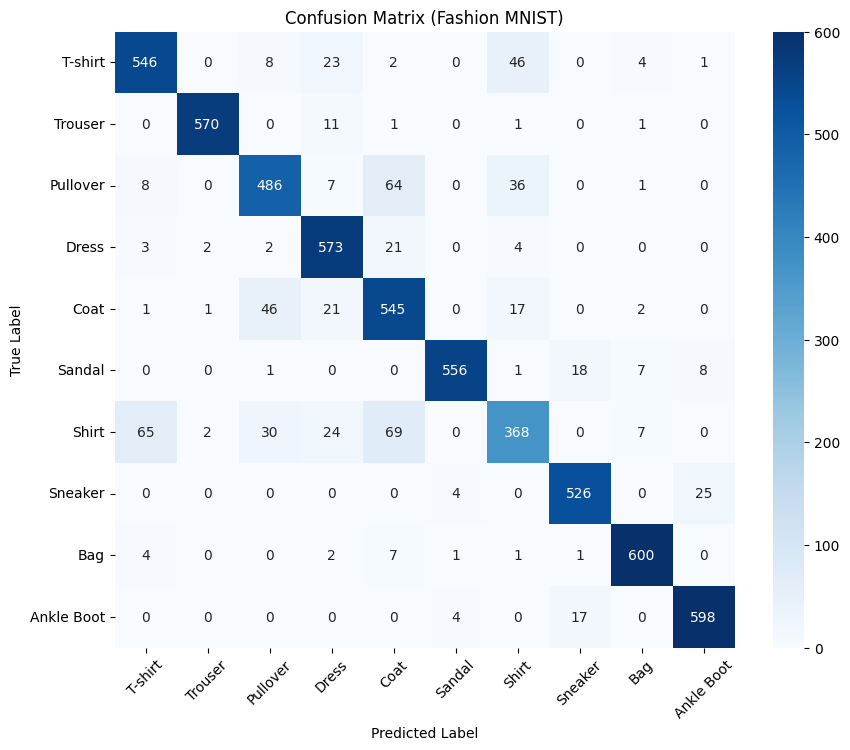

In [34]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix_named(X, Y, params, activation):
    class_names = [
        "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
    ]
    
    Y_hat, _ = forward_propagation(X, params, activation)
    
    preds = np.argmax(Y_hat, axis=0)
    labels = np.argmax(Y, axis=0)
    
    cm = confusion_matrix(labels, preds)
    
    plt.figure(figsize=(10,8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix (Fashion MNIST)")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    plt.show()
plot_confusion_matrix_named(X_val, Y_val, trained_params, "ReLU")

In [35]:
#mse
def compute_mse(Y_hat, Y):
    return np.mean((Y_hat - Y)**2)

In [36]:
Y_hat_test, _ = forward_propagation(X_test_flat, trained_params, "ReLU")

mse_loss = compute_mse(Y_hat_test, Y_test_oh)

print("Mean Squared Error:", mse_loss)

Mean Squared Error: 0.016771797399758658


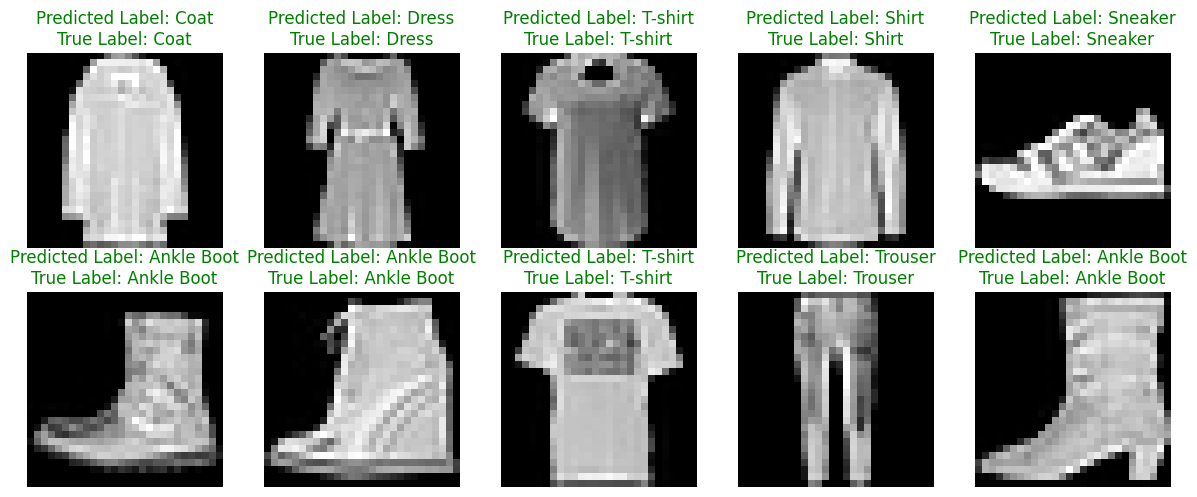

In [37]:
#testing predictions
import random

# class labels for Fashion MNIST
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

def show_random_predictions(X, Y, params, activation, num_samples=10):
    indices = np.random.choice(X.shape[1], num_samples, replace=False)
    
    plt.figure(figsize=(12,5))
    
    for i, idx in enumerate(indices):
        x = X[:, idx].reshape(-1,1)
        y_true = np.argmax(Y[:, idx])
        
        y_hat, _ = forward_propagation(x, params, activation)
        y_pred = np.argmax(y_hat)
        
        plt.subplot(2,5,i+1)
        plt.imshow(x.reshape(28,28), cmap='gray')
        plt.axis('off')
        
        color = "green" if y_pred == y_true else "red"
        
        plt.title(f"Predicted Label: {class_names[y_pred]}\nTrue Label: {class_names[y_true]}", color=color)
    
    plt.tight_layout()
    plt.show()
show_random_predictions(X_val, Y_val, trained_params, "ReLU")